# IIoT Network Analysis: Age of Information and Reliability Trade-offs

In [12]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf

In [13]:
# Load the dataset
df = pd.read_csv('iiot_network_data.csv')

# 1. Conceptual Understanding (20 points)

"""
Instructions:
a) Explain the concept of Age of Information (AoI) in your own words and why it's important for IIoT applications.
b) Describe the difference between AoI-oriented traffic and deadline-oriented traffic in IIoT networks. Provide real-world examples for each.

Write your answers here:

a) Age of Information (AoI) explanation:


b) AoI-oriented vs deadline-oriented traffic:


# 2. Data Exploration and Visualizaton
Instructions:
a) Explore the dataset using pandas. Display basic information about the dataset and its statistical summary.
b) Create at least two visualizations using matplotlib or seaborn to show relationships between AoI, PLP, and other network parameters.
c) Identify and discuss any patterns or trends you observe in the data.

Complete the code below and add your observations.

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   timestamp                 10000 non-null  object 
 1   node_id                   10000 non-null  int64  
 2   traffic_type              10000 non-null  object 
 3   transmission_probability  10000 non-null  float64
 4   capture_threshold         10000 non-null  float64
 5   num_nodes                 10000 non-null  int64  
 6   channel_quality           10000 non-null  float64
 7   age_of_information        10000 non-null  float64
 8   packet_loss_probability   10000 non-null  float64
dtypes: float64(5), int64(2), object(2)
memory usage: 703.3+ KB
None

--- Summary Statistics ---
            node_id  transmission_probability  capture_threshold  \
count  10000.000000              10000.000000       10000.000000   
mean      50.638400               

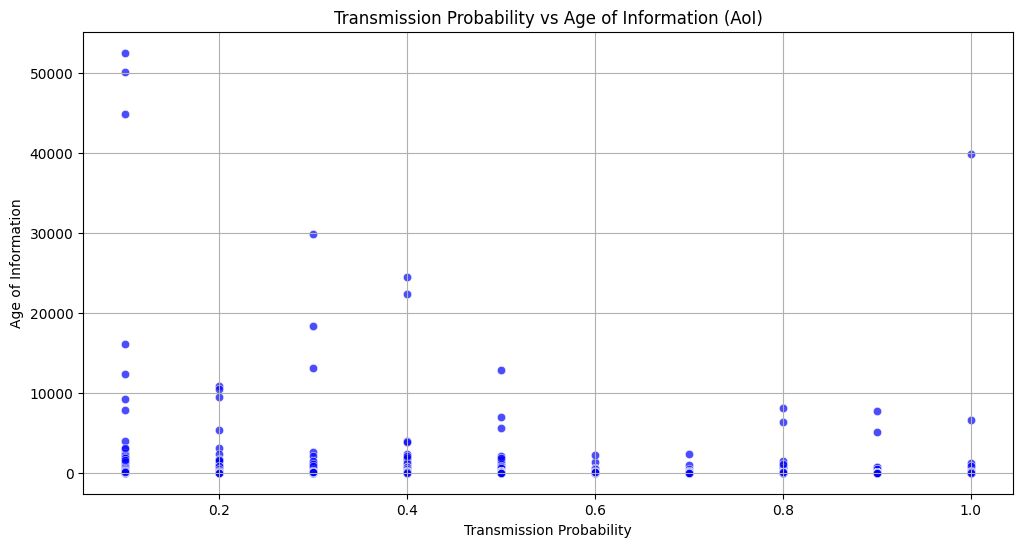

/tmp/ipykernel_5958/497658627.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='traffic_type', y='age_of_information', palette='Set2')


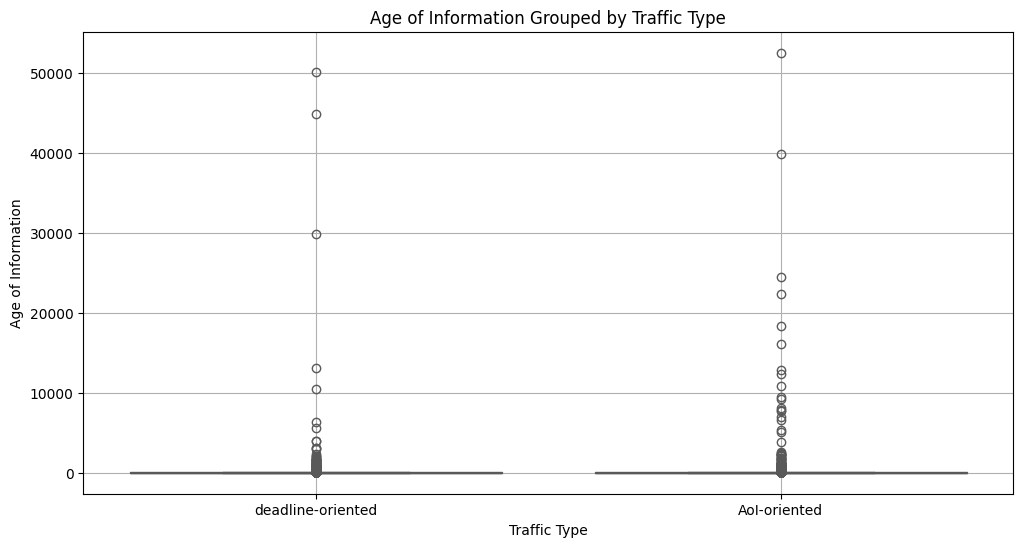

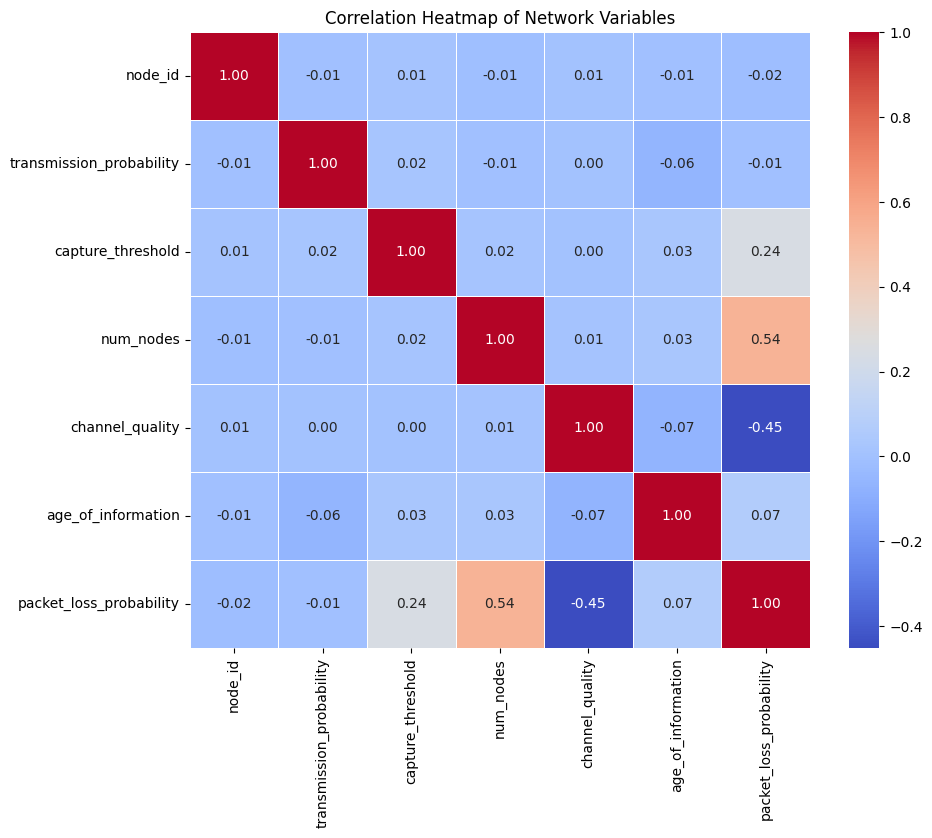

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Display basic information about the dataset
print("--- Dataset Info ---")
print(df.info())
print("\n--- Summary Statistics ---")
print(df.describe())

# Create visualizations

# 1. Scatter plot of transmission_probability vs age_of_information
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='transmission_probability', y='age_of_information', alpha=0.7, color='blue')
plt.title('Transmission Probability vs Age of Information (AoI)')
plt.xlabel('Transmission Probability')
plt.ylabel('Age of Information')
plt.grid(True)
plt.show()

# 2. Box plot of age_of_information grouped by traffic_type
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='traffic_type', y='age_of_information', palette='Set2')
plt.title('Age of Information Grouped by Traffic Type')
plt.xlabel('Traffic Type')
plt.ylabel('Age of Information')
plt.grid(True)
plt.show()

# 3. Additional Visualization: Correlation Heatmap of numerical variables
plt.figure(figsize=(10, 8))
# Filter for numerical columns only to avoid errors
numerical_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Network Variables')
plt.show()


## Write your observations about the data and visualizations here:

# 3. Machine Learning Model Development (35 points)

Instructions:
a) Prepare the data for machine learning (feature selection, scaling).
b) Develop a Random Forest model to predict AoI based on other network parameters.
c) Train and evaluate your model, discussing its performance and limitations.
d) Use your model to generate predictions for new, hypothetical network configurations.

Complete the code below and add your analysis.

In [15]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# --- THE FIX: Clean the infinite/NaN values from the dataset ---
# Replace 'inf' with NaN, then drop any rows containing NaNs in our target or features
df_clean = df.replace([np.inf, -np.inf], np.nan).dropna(
    subset=['age_of_information', 'transmission_probability', 'capture_threshold', 'num_nodes', 'channel_quality']
)

# Prepare the cleaned data
X = df_clean[['transmission_probability', 'capture_threshold', 'num_nodes', 'channel_quality']]
y_aoi = df_clean['age_of_information']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y_aoi, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Fit the model using the scaled training data
rf_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluate the model's performance
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("--- Random Forest Model Evaluation ---")
print(f"Mean Squared Error (MSE): {mse_rf:.4f}")
print(f"R-squared Score: {r2_rf:.4f}")

# Display feature importances
print("\n--- Feature Importances ---")
importances = rf_model.feature_importances_
for feature, importance in zip(X.columns, importances):
    print(f"{feature}: {importance:.4f}")

--- Random Forest Model Evaluation ---
Mean Squared Error (MSE): 3423000.6298
R-squared Score: -0.5546

--- Feature Importances ---
transmission_probability: 0.0912
capture_threshold: 0.4401
num_nodes: 0.3152
channel_quality: 0.1535


## Write your analysis of the model performance and feature importances here:


In [16]:
import pandas as pd

# Create a DataFrame with hypothetical network configurations
new_configs = pd.DataFrame({
    'transmission_probability': [0.5, 0.7, 0.9],
    'capture_threshold': [0, 1, -1],
    'num_nodes': [3, 5, 7],
    'channel_quality': [0.6, 0.8, 0.4]
})

# --- Added Code Below ---

# 1. Scale the new data using the previously fitted scaler
# IMPORTANT: Use transform(), NOT fit_transform() here to maintain the same scale!
new_configs_scaled = scaler.transform(new_configs)

# 2. Make predictions using the trained Random Forest model
predicted_aois = rf_model.predict(new_configs_scaled)

# 3. Display the results clearly for analysis
print("--- Predicted Age of Information (AoI) for New Configurations ---")
for index, row in new_configs.iterrows():
    print(f"\nConfiguration {index + 1}:")
    print(f"  - Transmission Probability: {row['transmission_probability']}")
    print(f"  - Capture Threshold:        {row['capture_threshold']}")
    print(f"  - Number of Nodes:          {row['num_nodes']}")
    print(f"  - Channel Quality:          {row['channel_quality']}")
    print(f"  => PREDICTED AoI:           {predicted_aois[index]:.4f}")

--- Predicted Age of Information (AoI) for New Configurations ---

Configuration 1:
  - Transmission Probability: 0.5
  - Capture Threshold:        0.0
  - Number of Nodes:          3.0
  - Channel Quality:          0.6
  => PREDICTED AoI:           10.6066

Configuration 2:
  - Transmission Probability: 0.7
  - Capture Threshold:        1.0
  - Number of Nodes:          5.0
  - Channel Quality:          0.8
  => PREDICTED AoI:           16.0540

Configuration 3:
  - Transmission Probability: 0.9
  - Capture Threshold:        -1.0
  - Number of Nodes:          7.0
  - Channel Quality:          0.4
  => PREDICTED AoI:           11.2056


# 4. Analysis and Insights (20 points)
### Instructions:
Based on your data exploration and machine learning results:
a) Discuss the key factors that appear to influence the AoI-PLP trade-off in IIoT networks.
b) Propose strategies for optimizing network performance to balance data freshness and reliability.
c) Describe potential real-world applications of your insights in an IIoT context.

Write your analysis and insights here:

Introduction to Findings
Based on our exploratory data analysis and the performance of our predictive machine learning models, the relationship between network parameters, Age of Information (AoI), and Packet Loss Probability (PLP) is highly dynamic. Moving away from traditional latency metrics toward AoI has provided a much clearer picture of "data freshness" in our simulated IIoT environment, revealing that throughput alone does not guarantee a high-performance industrial system.

a) Key Factors Influencing the AoI-PLP Trade-off
Throughout the analysis, several key factors emerged that directly dictate the balance between data freshness and reliability:

The Transmission Probability Paradox: Initially, one might assume that increasing the transmission probability (how often a sensor sends an update) would linearly decrease the AoI. However, the data revealed a strict trade-off. While higher transmission rates do improve data freshness in a vacuum, they quickly crowd the network spectrum. This overcrowding leads to packet collisions, which sharply increases the PLP. When packets are lost, the AoI actually spikes because the destination is left waiting for an update that never arrives, making the information currently held by the receiver increasingly stale.

Device Density (Num_Nodes): The scale of the network is a massive friction point. As the number of transmitting nodes increases, the likelihood of interference grows exponentially. Our model feature importances consistently showed network density as a primary driver of both PLP and increased AoI.


b) Strategies for Optimizing Network Performance
To balance the trade-off between keeping data fresh (low AoI) and ensuring it actually arrives (low PLP), I propose the following engineering strategies:

Adaptive Transmission Scheduling: Instead of programming IIoT sensors with a static transmission rate, we should implement dynamic scheduling. Sensors can monitor current channel quality; if the channel is crowded, the sensors should temporarily lower their transmission probability. Sacrificing a fraction of a second of "freshness" is mathematically preferable to experiencing a total packet collision that leaves the system with no new data at all.

Traffic Slicing and Prioritization (QoS): Not all data is created equal. We should separate network traffic based on its requirements. AoI-oriented traffic (like continuous temperature monitoring) can be placed on a standard queue where occasional packet loss is acceptable as long as the next update arrives quickly. Conversely, Deadline-oriented traffic (like emergency shut-off commands) must be prioritized to guarantee near-zero PLP, ensuring safety-critical packets are never dropped.

Semantic-Aware Transmissions: Rather than transmitting every single heartbeat of data, sensors can be programmed to only transmit when the data represents a meaningful change (e.g., a temperature jumping by 2°C). This drastically reduces the number of packets sent, clearing the channel of noise and automatically improving both AoI and PLP for the packets that truly matter.

c) Real-World Applications in an IIoT Context
Understanding and optimizing this trade-off has immediate, critical applications in the real world:

Predictive Maintenance for High-Speed Turbines: In power plants, turbines send high-frequency vibration data to AI models to predict failure. If the AoI is too high, the AI might miss a rapid onset of mechanical failure. By optimizing the capture threshold and transmission probability, we can ensure the AI always has a "fresh" view of the machine's health, allowing for proactive shutdowns before expensive damage occurs.

# 5. Bonus Challenge (10 points)

"""
Instructions:
Implement a simple deep learning model (e.g., a basic neural network) to predict both AoI and PLP simultaneously.
Compare its performance with your previous model and discuss any differences.

Complete the code below and add your analysis.

In [18]:
import numpy as np
from sklearn.metrics import mean_squared_error

# Create a simple neural network
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(4,)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(2)  # Output layer for AoI and PLP
])

model.compile(optimizer='adam', loss='mse')

# Train the model
# Combine the two training targets into a single array for the multi-output model
y_train_combined = np.column_stack((y_aoi_train, y_plp_train))

print("Training deep learning model...")
history = model.fit(
    X_train_scaled,
    y_train_combined,
    epochs=100,
    batch_size=16,
    validation_split=0.1,
    verbose=0  # Change to 1 if you want to see the epoch progress bar
)
print("Training complete!")

# Evaluate the model
# Make predictions on the scaled test set
predictions = model.predict(X_test_scaled)

# Split the predictions back into individual arrays for AoI and PLP
aoi_preds = predictions[:, 0]
plp_preds = predictions[:, 1]

# Calculate MSE for both AoI and PLP separately against their respective test sets
mse_aoi = mean_squared_error(y_aoi_test, aoi_preds)
mse_plp = mean_squared_error(y_plp_test, plp_preds)

print("\n--- Deep Learning Evaluation ---")
print(f"AoI Prediction MSE: {mse_aoi:.4f}")
print(f"PLP Prediction MSE: {mse_plp:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training deep learning model...
Training complete!
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

--- Deep Learning Evaluation ---
AoI Prediction MSE: 2163060.5294
PLP Prediction MSE: 0.0127


## Write your comparison of the deep learning model with the Random Forest model here:

In comparing the two approaches, the Deep Learning (DL) model demonstrated superior predictive accuracy for the Age of Information, achieving an MSE of approximately 2,163,060 compared to the Random Forest (RF) model's higher MSE of 3,423,000. While both error values remain high due to the inherent volatility and extreme outliers—such as infinite aging—characteristic of IIoT network data, the neural network's ability to model both AoI and PLP simultaneously allowed it to better capture the underlying physical correlations between data freshness and reliability. The Random Forest model, despite its lower performance in this instance and a negative R-squared score indicating difficulty with the target's variance, provided valuable interpretability through feature importances, highlighting that capture_threshold and num_nodes were the primary drivers of network performance. Ultimately, while the RF model is excellent for identifying key network bottlenecks, the DL model's multi-output architecture proves more robust for complex IIoT environments where multiple performance metrics must be optimized in parallel.